# 1.0 — Setup & Imports

Install required packages (Colab only), import all standard, scientific, and deep-learning
libraries, configure global seeds, and suppress non-critical warnings.

In [4]:
import os
import sys
import io
import gc
import json
import random
import shutil
import time
import warnings
import subprocess
from pathlib import Path

# --- Colab-specific setup ---
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'xlsxwriter'], check=True)

# --- Numeric / data ---
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# --- Visualisation ---
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# --- Global config ---
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2.0 — Configuration

Defines all path constants, hyper-parameters, and model metadata used throughout the notebook.
Paths are first resolved relative to Google Drive, then redirected to `/content/local_*` after
staging (see Section 3).

In [5]:
# --- Project root (Drive) ---
PROJECT_ROOT_CANDIDATES = [
    Path('/content/drive/My Drive/Classification'),
    Path('/content/drive/My Drive/Classification'),
    Path('/content/drive/My Drive/Classification'),
]
PROJECT_ROOT = next((p for p in PROJECT_ROOT_CANDIDATES if p.exists()), Path.cwd())

# --- Source directories (Drive) ---
DATA_DIR  = PROJECT_ROOT / 'data'

# Baseline trained .keras models
MODEL_DIR = PROJECT_ROOT / 'baseline' / 'models'

# DAPM artifacts (weights/configs/diffusion)
DAPM_DIR  = PROJECT_ROOT / 'dapm' / 'models' / 'dapm_full_artifacts'

# --- Output directories (Drive) — will be overridden to local below ---
OUTPUT_DIR = PROJECT_ROOT  / 'dapm' /'results'
CHUNK_DIR  = OUTPUT_DIR / 'chunk_outputs'
MAP_DIR    = OUTPUT_DIR / 'maps'
for d in [OUTPUT_DIR, CHUNK_DIR, MAP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Data files ---
DATA_FILE  = DATA_DIR / 'data.csv'
LABEL_FILE = DATA_DIR / 'ref.csv'

# --- Model registry ---
MODEL_KEYS = ['AlexNet_CNN', 'GFNet', 'ViT_UNet']
MODEL_FILES = {
    'AlexNet_CNN': MODEL_DIR / 'AlexNet_CNN_best.keras',
    'GFNet':       MODEL_DIR / 'GFNet_best.keras',
    'ViT_UNet':    MODEL_DIR / 'ViT_UNet_best.keras',
}
MODEL_NAME_MAP = {
    'AlexNet_CNN': 'AlexNet',
    'GFNet':       'GFNet',
    'ViT_UNet':    'ViT',
}

# --- Image / patch parameters ---
H, W, B    = 330, 307, 6
PATCH_SIZE = 9

# --- Sampling / inference parameters ---
N_SAMPLES        = 30
BATCH_SIZE       = 128
SCENE_CHUNK_SIZE = 1000
P_THRESH         = 0.05

# --- Output file paths (will be overridden to local after staging) ---
EXCEL_PATH           = OUTPUT_DIR / 'dapm_full_reports_all_models.xlsx'
SUMMARY_CSV_PATH     = OUTPUT_DIR / 'dapm_full_summary_metrics.csv'
RUN_CONFIG_JSON_PATH = OUTPUT_DIR / 'dapm_full_run_config.json'
PER_CLASS_CSV_PATH   = OUTPUT_DIR / 'dapm_full_per_class_metrics.csv'

# 3.0 — Local File Staging

Copies all model weights, DAPM artifact files, and data CSVs from Google Drive to local
`/content/local_*` paths. This avoids FUSE-related I/O errors during compute-intensive loops.
All path variables defined in Section 2 are redirected to their local equivalents here.

In [6]:
# --- Local staging directories ---
LOCAL_MODEL_DIR = Path('/content/local_models')

# Local copy of DAPM models
LOCAL_DAPM_DIR = Path('/content/local_dapm_models')

for d in [LOCAL_MODEL_DIR, LOCAL_DAPM_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- Stage base .keras model files ---
LOCAL_MODEL_FILES = {}
for mk, src_path in MODEL_FILES.items():
    dst_path = LOCAL_MODEL_DIR / src_path.name
    if not dst_path.exists():
        print(f'Copying {src_path.name} to local ...')
        shutil.copy2(str(src_path), str(dst_path))
    LOCAL_MODEL_FILES[mk] = dst_path
    print(f'  {mk}: {dst_path}  ({dst_path.stat().st_size / 1e6:.1f} MB)')

# --- Stage DAPM artifact files (configs + weights) ---
for f in DAPM_DIR.iterdir():
    dst = LOCAL_DAPM_DIR / f.name
    if not dst.exists():
        shutil.copy2(str(f), str(dst))

# Keep a Drive reference for the final copy-back step
LOCAL_DAPM_DIR_ORIG = DAPM_DIR

# --- Stage data CSV files ---
LOCAL_DATA_DIR = Path('/content/local_data')
LOCAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
for src in [DATA_FILE, LABEL_FILE]:
    dst = LOCAL_DATA_DIR / src.name
    if not dst.exists():
        print(f'Copying {src.name} to local ...')
        shutil.copy2(str(src), str(dst))

# --- Redirect all path variables to local copies ---
DAPM_DIR    = LOCAL_DAPM_DIR
MODEL_FILES = LOCAL_MODEL_FILES
DATA_FILE   = LOCAL_DATA_DIR / 'data.csv'
LABEL_FILE  = LOCAL_DATA_DIR / 'ref.csv'

OUTPUT_DIR = Path('/content/local_outputs/dapm_full')
CHUNK_DIR  = OUTPUT_DIR / 'chunk_outputs'
MAP_DIR    = OUTPUT_DIR / 'maps'
for d in [OUTPUT_DIR, CHUNK_DIR, MAP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

EXCEL_PATH           = OUTPUT_DIR / 'dapm_full_reports_all_models.xlsx'
SUMMARY_CSV_PATH     = OUTPUT_DIR / 'dapm_full_summary_metrics.csv'
RUN_CONFIG_JSON_PATH = OUTPUT_DIR / 'dapm_full_run_config.json'
PER_CLASS_CSV_PATH   = OUTPUT_DIR / 'dapm_full_per_class_metrics.csv'

print('\nAll files staged to local. Drive will not be accessed during compute.')
print('DAPM_DIR    =', DAPM_DIR)
print('MODEL_FILES =', MODEL_FILES)
print('DATA_FILE   =', DATA_FILE)

Copying AlexNet_CNN_best.keras to local ...
  AlexNet_CNN: /content/local_models/AlexNet_CNN_best.keras  (272.1 MB)
Copying GFNet_best.keras to local ...
  GFNet: /content/local_models/GFNet_best.keras  (127.3 MB)
Copying ViT_UNet_best.keras to local ...
  ViT_UNet: /content/local_models/ViT_UNet_best.keras  (194.1 MB)
Copying data.csv to local ...
Copying ref.csv to local ...

All files staged to local. Drive will not be accessed during compute.
DAPM_DIR    = /content/local_dapm_models
MODEL_FILES = {'AlexNet_CNN': PosixPath('/content/local_models/AlexNet_CNN_best.keras'), 'GFNet': PosixPath('/content/local_models/GFNet_best.keras'), 'ViT_UNet': PosixPath('/content/local_models/ViT_UNet_best.keras')}
DATA_FILE   = /content/local_data/data.csv


# 4.0 — Data Pipeline

Loads the 6-band multispectral image and label map from CSV, normalises each spectral band
independently to [0, 1], and builds pixel coordinate arrays for both the full scene and
the labelled subset.

In [7]:
def load_multispectral_6band(data_path, label_path, h, w, b):
    """Load and per-band normalise a multispectral image + label map from CSV files."""
    x = pd.read_csv(data_path).to_numpy(dtype=np.float32).reshape(h, w, b)
    y = pd.read_csv(label_path).to_numpy(dtype=np.int32).reshape(h, w)
    x_norm = np.empty_like(x, dtype=np.float32)
    for bi in range(b):
        band  = x[:, :, bi]
        mn, mx = float(np.min(band)), float(np.max(band))
        denom  = max(mx - mn, 1e-8)
        x_norm[:, :, bi] = (band - mn) / denom
    return x_norm, y


def extract_patches_from_coords(x_img, coords, patch_size=9):
    """Extract fixed-size spatial patches centred on the given (row, col) coordinates."""
    pad   = patch_size // 2
    x_pad = np.pad(x_img, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    out   = np.empty(
        (coords.shape[0], patch_size, patch_size, x_img.shape[-1]), dtype=np.float32
    )
    for i, (r, c) in enumerate(coords):
        out[i] = x_pad[r:r + patch_size, c:c + patch_size, :]
    return out

In [8]:
# Load image and labels, then build coordinate arrays
x_img, y_img = load_multispectral_6band(DATA_FILE, LABEL_FILE, H, W, B)

coords_scene   = np.argwhere(np.ones((H, W), dtype=bool))   # all pixels
coords_labeled = np.argwhere(y_img > 0)                      # only labelled pixels
y_labeled      = np.array(
    [int(y_img[r, c]) - 1 for r, c in coords_labeled], dtype=np.int32
)
num_classes = int(np.unique(y_img[y_img > 0]).size)

print('x_img:',          x_img.shape,          'y_img:', y_img.shape)
print('coords_scene:',   coords_scene.shape)
print('coords_labeled:', coords_labeled.shape)
print('num_classes:',    num_classes)

x_img: (330, 307, 6) y_img: (330, 307)
coords_scene: (101310, 2)
coords_labeled: (17239, 2)
num_classes: 7


# 5.0 — Custom Keras Layers

Defines and registers all custom `tf.keras.layers.Layer` subclasses needed to deserialise
the pre-trained `.keras` model files. These layers implement patch extraction, positional
encoding, frequency-domain filtering, CLS-token encoding, and the VAE reparameterisation trick.

In [9]:
@tf.keras.utils.register_keras_serializable()
class PatchExtractor(layers.Layer):
    """Extract non-overlapping image patches using tf.image.extract_patches."""

    def __init__(self, patch_size=3, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding='VALID',
        )
        batch      = tf.shape(images)[0]
        num_patches = tf.shape(patches)[1] * tf.shape(patches)[2]
        patch_dim  = tf.shape(patches)[-1]
        return tf.reshape(patches, [batch, num_patches, patch_dim])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'patch_size': self.patch_size})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchPositionEncoder(layers.Layer):
    """Project patches to `projection_dim` and add learned positional embeddings."""

    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches     = num_patches
        self.projection_dim  = projection_dim
        self.projection       = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patches):
        positions = tf.range(start=0, limit=self.num_patches, delta=1)
        return self.projection(patches) + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class GlobalFilterLayer(layers.Layer):
    """Apply learnable complex-valued frequency-domain filters via 2-D FFT (GFNet)."""

    def __init__(self, token_side, **kwargs):
        super().__init__(**kwargs)
        self.token_side = token_side

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.w_real = self.add_weight(
            name='w_real', shape=(self.token_side, self.token_side, channels),
            initializer='glorot_uniform', trainable=True
        )
        self.w_imag = self.add_weight(
            name='w_imag', shape=(self.token_side, self.token_side, channels),
            initializer='zeros', trainable=True
        )
        super().build(input_shape)

    def call(self, x):
        batch    = tf.shape(x)[0]
        channels = tf.shape(x)[-1]
        x_2d      = tf.reshape(x, [batch, self.token_side, self.token_side, channels])
        x_fft     = tf.signal.fft2d(tf.cast(x_2d, tf.complex64))
        w_complex  = tf.complex(self.w_real, self.w_imag)
        x_filtered = x_fft * w_complex
        x_spatial  = tf.math.real(tf.signal.ifft2d(x_filtered))
        return tf.reshape(x_spatial, [batch, self.token_side * self.token_side, channels])

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'token_side': self.token_side})
        return cfg


@tf.keras.utils.register_keras_serializable()
class PatchEncoderWithCLS(layers.Layer):
    """Prepend a learnable CLS token and add positional embeddings (ViT-style)."""

    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches     = num_patches
        self.projection_dim  = projection_dim
        self.projection       = layers.Dense(projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches + 1, output_dim=projection_dim
        )

    def build(self, input_shape):
        self.cls_token = self.add_weight(
            name='cls_token', shape=(1, 1, self.projection_dim),
            initializer='zeros', trainable=True
        )
        super().build(input_shape)

    def call(self, patches):
        batch      = tf.shape(patches)[0]
        patch_proj = self.projection(patches)
        cls_tokens = tf.repeat(self.cls_token, repeats=batch, axis=0)
        x          = tf.concat([cls_tokens, patch_proj], axis=1)
        positions  = tf.range(start=0, limit=self.num_patches + 1, delta=1)
        return x + self.position_embedding(positions)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'num_patches': self.num_patches, 'projection_dim': self.projection_dim})
        return cfg


@tf.keras.utils.register_keras_serializable()
class Sampling(layers.Layer):
    """VAE reparameterisation trick: sample z from N(z_mu, exp(0.5 * z_logvar))."""

    def call(self, inputs):
        z_mu, z_logvar = inputs
        eps = tf.random.normal(shape=tf.shape(z_mu))
        return z_mu + tf.exp(0.5 * z_logvar) * eps


# Registry dict passed to keras.models.load_model
CUSTOM_OBJECTS = {
    'PatchExtractor':      PatchExtractor,
    'PatchPositionEncoder': PatchPositionEncoder,
    'GlobalFilterLayer':   GlobalFilterLayer,
    'PatchEncoderWithCLS': PatchEncoderWithCLS,
}

# 6.0 — DAPM Model Builders

Constructs the four sub-networks of the Diffusion-Augmented Probabilistic Model (DAPM):
a feature extractor (from the frozen base model), a VAE encoder, a softmax classifier,
and a conditional diffusion denoiser. Also defines the cosine beta schedule and the
bundle loader that assembles everything from saved weights.

In [10]:
def get_feature_extractor(base_model):
    """Wrap the penultimate layer of a Keras model as a frozen feature extractor."""
    penultimate = base_model.layers[-2].output
    feat_model  = keras.Model(
        base_model.input, penultimate,
        name=f'{base_model.name}_feature_extractor'
    )
    feat_model.trainable = False
    return feat_model


def build_dapm_encoder(feature_dim, latent_dim=64, hidden_dim=256):
    """Build the VAE encoder: features → (z_mu, z_logvar, z_sample)."""
    inp     = keras.Input(shape=(feature_dim,), name='enc_feature_in')
    h       = layers.Dense(hidden_dim, activation='relu', name='enc_h1')(inp)
    h       = layers.Dense(hidden_dim, activation='relu', name='enc_h2')(h)
    z_mu    = layers.Dense(latent_dim, name='z_mu')(h)
    z_logvar = layers.Dense(latent_dim, name='z_logvar')(h)
    z       = Sampling(name='z_sample')([z_mu, z_logvar])
    return keras.Model(inp, [z_mu, z_logvar, z], name='dapm_full_encoder')


def build_dapm_classifier(latent_dim, num_classes, hidden_dim=128):
    """Build the latent-space softmax classifier: z → class probabilities."""
    inp = keras.Input(shape=(latent_dim,), name='clf_z_in')
    h   = layers.Dense(hidden_dim, activation='relu', name='clf_h1')(inp)
    out = layers.Dense(num_classes, activation='softmax', name='clf_out')(h)
    return keras.Model(inp, out, name='dapm_full_classifier')


def build_dapm_diffusion(latent_dim, num_classes, T=100, t_embed_dim=32, hidden_dim=256):
    """Build the conditional diffusion denoiser: (z, y_t, guidance, t) → eps_pred."""
    z_in   = keras.Input(shape=(latent_dim,),   name='diff_z_in')
    y_t_in = keras.Input(shape=(num_classes,),  name='diff_y_t')
    f_in   = keras.Input(shape=(num_classes,),  name='diff_guidance')
    t_in   = keras.Input(shape=(1,), dtype='int32', name='diff_t')
    t_emb  = layers.Embedding(input_dim=T + 1, output_dim=t_embed_dim, name='diff_t_embed')(t_in)
    t_emb  = layers.Flatten(name='diff_t_flat')(t_emb)
    x      = layers.Concatenate(name='diff_concat')([z_in, y_t_in, f_in, t_emb])
    x      = layers.Dense(hidden_dim, activation='relu', name='diff_h1')(x)
    x      = layers.Dense(hidden_dim, activation='relu', name='diff_h2')(x)
    eps_pred = layers.Dense(num_classes, activation='linear', name='diff_eps_pred')(x)
    return keras.Model([z_in, y_t_in, f_in, t_in], eps_pred, name='dapm_full_diffusion')


def make_beta_schedule(T, beta_start=1e-4, beta_end=2e-2):
    """Linear beta schedule → (betas, alphas, cumulative alpha_bars)."""
    betas      = np.linspace(beta_start, beta_end, T, dtype=np.float32)
    alphas     = 1.0 - betas
    alpha_bars = np.cumprod(alphas)
    return betas, alphas, alpha_bars

In [11]:
def load_dapm_bundle(model_key):
    """
    Load a complete DAPM bundle for `model_key`.

    Reads the JSON config, loads the base feature extractor, builds all sub-networks,
    performs a warm-up forward pass to materialise shapes, loads saved weights,
    and returns a dict with all components plus the diffusion schedule.
    """
    cfg_path = DAPM_DIR / f'{model_key}_dapm_full_config.json'
    if not cfg_path.exists():
        raise FileNotFoundError(f'Missing config: {cfg_path}')
    cfg = json.loads(cfg_path.read_text(encoding='utf-8'))

    base_model_path = MODEL_FILES[model_key]
    if not base_model_path.exists():
        raise FileNotFoundError(f'Missing local base model: {base_model_path}')

    print(f'  Loading base model from: {base_model_path}')
    base_model = keras.models.load_model(
        str(base_model_path), custom_objects=CUSTOM_OBJECTS,
        compile=False, safe_mode=False
    )
    feature_extractor = get_feature_extractor(base_model)

    feature_dim     = int(cfg['feature_dim'])
    latent_dim      = int(cfg['latent_dim'])
    num_classes_cfg = int(cfg['num_classes'])

    encoder    = build_dapm_encoder(
        feature_dim, latent_dim=latent_dim,
        hidden_dim=int(cfg['decoder_hidden_dim'])
    )
    classifier = build_dapm_classifier(
        latent_dim, num_classes_cfg,
        hidden_dim=int(cfg['classifier_hidden_dim'])
    )
    diffusion  = build_dapm_diffusion(
        latent_dim, num_classes_cfg,
        T=int(cfg['diffusion_T']),
        t_embed_dim=int(cfg.get('t_embed_dim', 32)),
        hidden_dim=int(cfg['diffusion_hidden_dim'])
    )

    # Warm-up forward pass to build all layer shapes before loading weights
    feat_dummy            = tf.zeros((1, feature_dim), dtype=tf.float32)
    z_mu_d, z_logvar_d, z_d = encoder(feat_dummy, training=False)
    y_guidance_d          = classifier(z_d, training=False)
    _                     = diffusion(
        [z_d, y_guidance_d, y_guidance_d, tf.ones((1, 1), dtype=tf.int32)],
        training=False
    )

    # Load saved weights
    encoder.load_weights(str(DAPM_DIR / f'{model_key}_dapm_full_encoder.weights.h5'))
    classifier.load_weights(str(DAPM_DIR / f'{model_key}_dapm_full_classifier.weights.h5'))
    diffusion.load_weights(str(DAPM_DIR / f'{model_key}_dapm_full_diffusion.weights.h5'))
    print(f'  Weights loaded for {model_key}')

    betas, alphas, alpha_bars = make_beta_schedule(
        int(cfg['diffusion_T']),
        beta_start=float(cfg['beta_start']),
        beta_end=float(cfg['beta_end'])
    )
    return {
        'cfg':               cfg,
        'feature_extractor': feature_extractor,
        'encoder':           encoder,
        'classifier':        classifier,
        'diffusion':         diffusion,
        'betas':             betas,
        'alphas':            alphas,
        'alpha_bars':        alpha_bars,
        'T':                 int(cfg['diffusion_T']),
        'num_classes':       num_classes_cfg,
    }

# 7.0 — Utility Functions

All helper functions used by the main pipeline. Split into four logical sub-groups:
inference / computation, visualisation / plotting, Excel I/O, and the per-model output assembler.

## 7.1 — Inference & Computation Utilities

Implements the reverse diffusion sampler (with a compiled TF step function for speed),
the chunked DAPM sampler that tiles latent samples, and the Welch t-test uncertainty estimator.

In [12]:
def softmax_np(x, axis=-1):
    """Numerically stable softmax in NumPy."""
    x   = np.asarray(x, dtype=np.float32)
    x   = x - np.max(x, axis=axis, keepdims=True)
    ex  = np.exp(x)
    den = np.sum(ex, axis=axis, keepdims=True)
    den = np.where(den <= 1e-8, 1.0, den)
    return ex / den


@tf.function(reduce_retracing=True)
def _diffusion_step_compiled(diffusion_model, z_tf, y_tf, guidance_tf, t_tf):
    """Single compiled diffusion denoising step (traced for speed)."""
    return diffusion_model([z_tf, y_tf, guidance_tf, t_tf], training=False)


def reverse_diffusion(bundle, z_np, guidance_np):
    """
    Run the full reverse diffusion chain (T → 1) for a batch of latent codes.

    Returns softmax-normalised class probabilities of shape (n, num_classes).
    """
    diffusion  = bundle['diffusion']
    T          = int(bundle['T'])
    alphas     = bundle['alphas']
    alpha_bars = bundle['alpha_bars']
    betas      = bundle['betas']
    nc         = int(bundle['num_classes'])
    n          = z_np.shape[0]

    z_tf        = tf.constant(z_np, dtype=tf.float32)
    guidance_tf = tf.constant(guidance_np, dtype=tf.float32)
    y           = tf.random.normal((n, nc), dtype=tf.float32)

    for step in range(T, 0, -1):
        t_arr    = tf.cast(tf.fill((n, 1), step), tf.int32)
        eps_pred = _diffusion_step_compiled(diffusion, z_tf, y, guidance_tf, t_arr)

        alpha     = float(alphas[step - 1])
        alpha_bar = float(alpha_bars[step - 1])
        beta      = float(betas[step - 1])
        coef      = (1.0 - alpha) / max(np.sqrt(1.0 - alpha_bar), 1e-8)
        y         = (y - coef * eps_pred) / max(np.sqrt(alpha), 1e-8)

        if step > 1:
            noise = tf.random.normal(tf.shape(y), dtype=tf.float32)
            y     = y + np.sqrt(max(beta, 1e-8)) * noise

    return softmax_np(y.numpy(), axis=-1)


def sample_dapm_chunk(bundle, x_chunk, n_samples, batch_size):
    """
    Run `n_samples` diffusion draws for a chunk of input patches.

    Returns an array of shape (n_samples, n_points, num_classes).
    """
    x_chunk  = np.asarray(x_chunk, dtype=np.float32)
    n_points = x_chunk.shape[0]
    nc       = int(bundle['num_classes'])
    fe, enc, clf = bundle['feature_extractor'], bundle['encoder'], bundle['classifier']

    # Encode to latent space
    x_tf              = tf.constant(x_chunk, dtype=tf.float32)
    feat              = fe(x_tf, training=False)
    z_mu, z_logvar, _ = enc(feat, training=False)
    z_mu_np           = z_mu.numpy()
    std_np            = np.exp(0.5 * z_logvar.numpy()).astype(np.float32)
    guidance_np       = clf(z_mu, training=False).numpy()

    # Tile for n_samples stochastic draws
    z_mu_tiled     = np.tile(z_mu_np, (n_samples, 1))
    std_tiled      = np.tile(std_np, (n_samples, 1))
    guidance_tiled = np.tile(guidance_np, (n_samples, 1))
    eps            = np.random.normal(size=z_mu_tiled.shape).astype(np.float32)
    z_all          = (z_mu_tiled + std_tiled * eps).astype(np.float32)

    probs_flat = reverse_diffusion(bundle, z_all, guidance_tiled)
    return probs_flat.reshape(n_samples, n_points, nc)


def _safe_ttest_ind(g1, g2):
    """Welch t-test with graceful handling of constant / degenerate inputs."""
    g1, g2 = np.asarray(g1, dtype=np.float64), np.asarray(g2, dtype=np.float64)
    if np.allclose(g1, g1[0]) and np.allclose(g2, g2[0]):
        if abs(float(np.mean(g1)) - float(np.mean(g2))) < 1e-8:
            return 0.0, 1.0
        return np.inf, 0.0
    out  = ttest_ind(g1, g2, equal_var=False, nan_policy='omit')
    tval = float(np.nan_to_num(out.statistic, nan=0.0, posinf=np.inf, neginf=-np.inf))
    pval = float(np.nan_to_num(out.pvalue,    nan=1.0, posinf=1.0,   neginf=0.0))
    return tval, float(np.clip(pval, 0.0, 1.0))


def compute_dapm_ttest_uncertainty_chunk(probs_samples, p_thresh=0.05):
    """
    Estimate per-pixel uncertainty via Welch t-test on the top-2 class probability distributions.

    A pixel is marked uncertain when the top-1 vs top-2 p-value exceeds `p_thresh`.
    Returns a dict with pred_class, uncertain_mask, p_values, and top1_top2_mean_gap.
    """
    probs_samples                 = np.asarray(probs_samples, dtype=np.float32)
    n_samples, n_points, n_classes = probs_samples.shape

    pred_class     = np.empty((n_points,), dtype=np.int32)
    uncertain_mask = np.empty((n_points,), dtype=bool)
    p_values       = np.empty((n_points,), dtype=np.float32)
    mean_gap       = np.empty((n_points,), dtype=np.float32)

    mean_prob = np.mean(probs_samples, axis=0)
    order     = np.argsort(-mean_prob, axis=1)  # descending by mean prob

    for i in range(n_points):
        c1, c2 = int(order[i, 0]), int(order[i, 1])
        g1, g2 = probs_samples[:, i, c1], probs_samples[:, i, c2]
        _, pval = _safe_ttest_ind(g1, g2)
        pred_class[i]     = c1
        p_values[i]       = pval
        mean_gap[i]       = float(np.mean(g1) - np.mean(g2))
        uncertain_mask[i] = bool(pval > p_thresh)

    return {
        'pred_class':        pred_class,
        'uncertain_mask':    uncertain_mask,
        'p_values':          p_values,
        'top1_top2_mean_gap': mean_gap,
    }

## 7.2 — Visualisation Utilities

Plot generators for maps, distributions, and per-class metrics. Each function returns a
`BytesIO` PNG buffer ready for inline display or insertion into Excel.

In [13]:
# --- Colour palette constants ---
CLASS_COLOR_BASE = [
    '#0000FF', '#00FF00', '#FF0000', '#00FFFF', '#FF00FF',
    '#FFFF00', '#A52A2A', '#FFA500', '#7FFF00', '#8A2BE2',
]
UNCERTAIN_COLOR = '#808080'


def get_class_colors(n):
    """Return `n` distinct hex colour strings, falling back to tab20 for large n."""
    if n <= len(CLASS_COLOR_BASE):
        return CLASS_COLOR_BASE[:n]
    colors = CLASS_COLOR_BASE.copy()
    cmap   = plt.cm.get_cmap('tab20', n)
    for i in range(len(colors), n):
        c = cmap(i)
        colors.append('#%02x%02x%02x' % (int(c[0]*255), int(c[1]*255), int(c[2]*255)))
    return colors[:n]


def fig_to_buf(fig):
    """Render a Matplotlib figure to a PNG BytesIO buffer and close the figure."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=180, bbox_inches='tight')
    buf.seek(0)
    plt.close(fig)
    return buf


def add_bar_labels(ax, fmt='{:.2f}', y_pad=0.01):
    """Add value labels above each bar in a Matplotlib bar chart."""
    ymax = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if np.isnan(h):
            continue
        ax.text(
            p.get_x() + p.get_width() / 2, h + y_pad * ymax,
            fmt.format(h), ha='center', va='bottom', fontsize=9
        )


def make_certain_uncertain_map(uncertain_mask_map, title):
    """Binary spatial map: yellow = certain, dark blue = uncertain."""
    cmap = ListedColormap(['#FFFF00', '#001F3F'])
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(uncertain_mask_map.astype(int), cmap=cmap, interpolation='nearest')
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    ax.legend(
        handles=[
            Patch(facecolor='#FFFF00', edgecolor='black', label='Certain'),
            Patch(facecolor='#001F3F', edgecolor='black', label='Uncertain'),
        ],
        loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True
    )
    fig.tight_layout()
    return fig_to_buf(fig)


def make_class_uncertain_mask(combined_map, nc, title):
    """Spatial map of predicted classes with uncertain pixels shown in grey."""
    cmap = ListedColormap(get_class_colors(nc) + [UNCERTAIN_COLOR])
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(combined_map, cmap=cmap, vmin=0, vmax=nc, interpolation='nearest')
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    cbar = fig.colorbar(im, ax=ax, ticks=np.arange(nc + 1), fraction=0.046, pad=0.04)
    cbar.set_ticklabels([f'Class {i}' for i in range(nc)] + ['Uncertain'])
    fig.tight_layout()
    return fig_to_buf(fig)


def make_pixel_counts_plot(pcdf, nc, title):
    """Bar chart of pixel counts per class plus the uncertain category."""
    colors = get_class_colors(nc) + [UNCERTAIN_COLOR]
    labels = pcdf['label'].tolist()
    counts = pcdf['pixel_count'].tolist()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(labels, counts, color=colors[:len(labels)], edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Number of Pixels')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)
    ymax = max(counts) if counts else 1
    for i, v in enumerate(counts):
        ax.text(i, v + 0.01 * ymax, f'{int(v):,}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    fig.tight_layout()
    return fig_to_buf(fig)


def make_pvalue_hist(pvals_map, p_thresh, title):
    """Histogram of Welch t-test p-values with threshold line."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(pvals_map.ravel(), bins=50, color='steelblue', edgecolor='black', alpha=0.85)
    ax.axvline(p_thresh, color='red', ls='--', lw=2, label=f'Threshold (p={p_thresh})')
    ax.set_xlabel('Welch t-test p-value')
    ax.set_ylabel('Pixel Count')
    ax.set_title(title, fontsize=14)
    ax.legend()
    ax.grid(axis='y', ls='--', alpha=0.4)
    fig.tight_layout()
    return fig_to_buf(fig)


def make_gap_hist(gap_map, title):
    """Histogram of the top-1 minus top-2 mean probability gap."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(gap_map.ravel(), bins=50, color='darkorange', edgecolor='black', alpha=0.85)
    ax.set_xlabel('Top-1 minus Top-2 Mean Prob Gap')
    ax.set_ylabel('Pixel Count')
    ax.set_title(title, fontsize=14)
    ax.grid(axis='y', ls='--', alpha=0.4)
    fig.tight_layout()
    return fig_to_buf(fig)


def make_per_class_accuracy_plot(pcdf, title):
    """Bar chart of per-class accuracy on labelled pixels."""
    labels = [f'Class {int(c)}' for c in pcdf['class_id']]
    vals   = pcdf['class_accuracy'].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.bar(labels, vals, color=get_class_colors(len(labels)), edgecolor='black')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=9)
    fig.tight_layout()
    return fig_to_buf(fig)


def make_per_class_uncertainty_plot(pcdf, title):
    """Bar chart of per-class uncertainty rate on labelled pixels."""
    labels = [f'Class {int(c)}' for c in pcdf['class_id']]
    vals   = pcdf['uncertainty_rate'].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(labels, vals, color='#d62728', edgecolor='black', alpha=0.8)
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Uncertainty Rate')
    ax.set_ylim(0, max(0.1, float(np.nanmax(vals)) * 1.3) if len(vals) else 0.1)
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)
    add_bar_labels(ax, fmt='{:.3f}')
    fig.tight_layout()
    return fig_to_buf(fig)


def make_per_class_pvalue_plot(pcdf, p_thresh, title):
    """Bar chart of per-class mean p-value with threshold reference line."""
    labels = [f'Class {int(c)}' for c in pcdf['class_id']]
    vals   = pcdf['mean_p_value'].to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(labels, vals, color='#1f77b4', edgecolor='black', alpha=0.8)
    ax.axhline(p_thresh, color='red', ls='--', lw=1.5, label=f'Threshold (p={p_thresh})')
    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Mean p-value')
    ax.set_ylim(0, max(0.1, float(np.nanmax(vals)) * 1.3) if len(vals) else 0.1)
    ax.legend()
    ax.grid(axis='y', ls='--', alpha=0.4)
    ax.tick_params(axis='x', rotation=45)
    add_bar_labels(ax, fmt='{:.4f}')
    fig.tight_layout()
    return fig_to_buf(fig)

## 7.3 — Excel I/O Utilities

Helpers for naming Excel sheets, inserting image buffers, writing per-model detail sheets,
and writing the cross-model comparison sheet.

In [14]:
def sanitize_sheet_name(name):
    """Strip characters forbidden in Excel sheet names and truncate to 31 chars."""
    for ch in ['\\', '/', '*', '?', ':', '[', ']']:
        name = name.replace(ch, '_')
    return name[:31]


def make_sheet_name(base, used):
    """Return a unique Excel sheet name derived from `base`, tracking used names in `used`."""
    base = sanitize_sheet_name(base)
    out  = base
    i    = 1
    while out in used:
        suf = f'_{i}'
        out = base[:31 - len(suf)] + suf
        i  += 1
    used.add(out)
    return out


def insert_buf_img(ws, row, col, buf, x_scale=0.75, y_scale=0.75):
    """Insert a PNG BytesIO buffer as an image into an xlsxwriter worksheet."""
    buf.seek(0)
    ws.insert_image(row, col, 'plot.png',
                    {'image_data': buf, 'x_scale': x_scale, 'y_scale': y_scale})


def write_model_sheet(writer, workbook, output, sheet_name):
    """Write tables and plots for a single model to a named Excel worksheet."""
    ws   = workbook.add_worksheet(sheet_name)
    writer.sheets[sheet_name] = ws
    bold = workbook.add_format({'bold': True, 'font_size': 12})
    row  = 0
    ws.write(row, 0, f"DAPM — {output['model_name']}", bold)
    row += 2
    for tname, tdf in output['tables'].items():
        ws.write(row, 0, tname, bold)
        tdf.to_excel(writer, sheet_name=sheet_name, startrow=row + 1, startcol=0, index=False)
        row += len(tdf) + 4
    img_row, img_col = 0, 9
    for pname, pbuf in output['plot_buffers'].items():
        ws.write(img_row, img_col, pname)
        insert_buf_img(ws, img_row + 1, img_col, pbuf, 0.72, 0.72)
        img_row += 24


def write_comparison_sheet(writer, workbook, sheet_name, sdf, comp_bufs):
    """Write the cross-model comparison summary table and plots to an Excel worksheet."""
    ws   = workbook.add_worksheet(sheet_name)
    writer.sheets[sheet_name] = ws
    bold = workbook.add_format({'bold': True, 'font_size': 12})
    ws.write(0, 0, 'DAPM Uncertainty: 3-Model Comparison', bold)
    sdf.to_excel(writer, sheet_name=sheet_name, startrow=2, startcol=0, index=False)
    img_row = 2 + len(sdf) + 3
    for pname, pbuf in comp_bufs.items():
        ws.write(img_row, 0, pname, bold)
        insert_buf_img(ws, img_row + 1, 0, pbuf, 0.78, 0.78)
        img_row += 28

## 7.4 — Per-Model Output Assembler

Takes raw per-pixel arrays (predictions, uncertainty mask, p-values, gaps) and assembles
the complete output dict: reshaped spatial maps, per-class metrics, summary statistics,
all plot buffers, and tables — ready for Excel and Drive export.

In [15]:
def build_pixel_counts_df(combined_map, nc):
    """Build a DataFrame of pixel counts per class plus the uncertain category."""
    uniq, cnt = np.unique(combined_map, return_counts=True)
    counts    = {int(k): int(v) for k, v in zip(uniq, cnt)}
    rows = [
        {'class_id': c, 'label': f'Class {c}', 'pixel_count': counts.get(c, 0)}
        for c in range(nc)
    ]
    rows.append({'class_id': nc, 'label': 'Uncertain', 'pixel_count': counts.get(nc, 0)})
    return pd.DataFrame(rows)


def build_dapm_outputs(
    model_name, model_key,
    pred_class_all, uncertain_mask_all, p_values_all, gaps_all,
    num_classes, runtime_sec
):
    """
    Assemble the full output dict for one model.

    Reshapes flat pixel arrays into (H, W) maps, computes overall and per-class metrics
    on labelled pixels, generates all plot buffers, and packages everything into a
    structured dict for downstream saving / Excel writing.
    """
    pred_map  = pred_class_all.reshape(H, W)
    unc_map   = uncertain_mask_all.reshape(H, W)
    pval_map  = p_values_all.reshape(H, W)
    gap_map   = gaps_all.reshape(H, W)
    combo_map = np.where(unc_map, num_classes, pred_map)  # uncertain pixels → class index nc

    # Restrict metrics to labelled pixels
    idx      = coords_labeled[:, 0] * W + coords_labeled[:, 1]
    lbl_pred = pred_class_all[idx]
    lbl_unc  = uncertain_mask_all[idx]
    lbl_pval = p_values_all[idx]
    lbl_gap  = gaps_all[idx]

    oa        = float(np.mean(lbl_pred == y_labeled))
    unc_count = int(np.sum(uncertain_mask_all))
    unc_rate  = float(unc_count / (H * W))

    pc_rows = []
    for c in range(num_classes):
        m   = (y_labeled == c)
        sup = int(m.sum())
        if sup == 0:
            pc_rows.append({'class_id': c, 'class_accuracy': np.nan,
                            'uncertainty_rate': np.nan, 'mean_p_value': np.nan,
                            'mean_gap': np.nan, 'support_count': 0})
            continue
        pc_rows.append({
            'class_id':        c,
            'class_accuracy':  float(np.mean(lbl_pred[m] == c)),
            'uncertainty_rate': float(np.mean(lbl_unc[m])),
            'mean_p_value':    float(np.mean(lbl_pval[m])),
            'mean_gap':        float(np.mean(lbl_gap[m])),
            'support_count':   sup,
        })
    per_cls_df = pd.DataFrame(pc_rows)
    pixel_df   = build_pixel_counts_df(combo_map, num_classes)

    summary = {
        'model_name': model_name, 'model_key': model_key, 'method': 'DAPM_TTest',
        'n_samples': N_SAMPLES, 'p_threshold': P_THRESH,
        'overall_accuracy_labeled':  oa,
        'uncertain_count':           unc_count,
        'uncertain_rate':            unc_rate,
        'certainty_rate':            1.0 - unc_rate,
        'mean_p_value':              float(np.mean(p_values_all)),
        'median_p_value':            float(np.median(p_values_all)),
        'mean_top1_top2_gap':        float(np.mean(gaps_all)),
        'runtime_sec':               runtime_sec,
        'mean_per_class_accuracy':   float(per_cls_df['class_accuracy'].mean(skipna=True)),
        'mean_per_class_uncertainty': float(per_cls_df['uncertainty_rate'].mean(skipna=True)),
    }

    plots = {
        'Certain vs Uncertain Map': make_certain_uncertain_map(
            unc_map, f'{model_name}: Certain vs Uncertain\n(DAPM t-test, p={P_THRESH})'),
        'Class + Uncertain Mask': make_class_uncertain_mask(
            combo_map, num_classes, f'{model_name}: Classification + Uncertainty Mask'),
        'Pixel Counts': make_pixel_counts_plot(
            pixel_df, num_classes, f'{model_name}: Pixel Counts (incl. Uncertain)'),
        'P-Value Distribution': make_pvalue_hist(
            pval_map, P_THRESH, f'{model_name}: P-Value Distribution'),
        'Top1-Top2 Gap Distribution': make_gap_hist(
            gap_map, f'{model_name}: Probability Gap Distribution'),
        'Per-Class Accuracy': make_per_class_accuracy_plot(
            per_cls_df, f'{model_name}: Per-Class Accuracy (Labeled)'),
        'Per-Class Uncertainty Rate': make_per_class_uncertainty_plot(
            per_cls_df, f'{model_name}: Per-Class Uncertainty Rate'),
        'Per-Class Mean P-Value': make_per_class_pvalue_plot(
            per_cls_df, P_THRESH, f'{model_name}: Per-Class Mean P-Value'),
    }

    tables = {
        'Summary':          pd.DataFrame([summary]),
        'Per-Class Metrics': per_cls_df,
        'Pixel Counts':     pixel_df,
        'Parameters':       pd.DataFrame([{
            'n_samples': N_SAMPLES, 'p_threshold': P_THRESH,
            'H': H, 'W': W, 'total_pixels': H * W,
            'labeled_pixels': len(y_labeled)
        }]),
    }

    return {
        'model_name': model_name, 'model_key': model_key,
        'method':     'DAPM_TTest', 'summary': summary,
        'per_class_df':    per_cls_df,
        'pixel_counts_df': pixel_df,
        'plot_buffers':    plots,
        'tables':          tables,
        'maps': {
            'pred_class':    pred_map,
            'uncertain_mask': unc_map,
            'p_value':       pval_map,
            'gap':           gap_map,
            'combined':      combo_map,
        },
    }


print('All utility functions ready.')

All utility functions ready.


# 8.0 — Main Computation Loop

Iterates over all three models. For each model: loads the DAPM bundle, processes the
full scene in `SCENE_CHUNK_SIZE`-pixel chunks (with chunk-level caching via `.npz` files),
assembles outputs, saves spatial maps and PNGs, then releases GPU memory.

In [16]:
all_outputs  = []
summary_rows = []

for model_key in MODEL_KEYS:
    model_name = MODEL_NAME_MAP.get(model_key, model_key)
    print('\n' + '=' * 25 + f' {model_name} ({model_key}) ' + '=' * 25)

    bundle       = load_dapm_bundle(model_key)
    n_points     = coords_scene.shape[0]
    total_chunks = int(np.ceil(n_points / SCENE_CHUNK_SIZE))

    pred_class_all     = np.empty((n_points,), dtype=np.int32)
    uncertain_mask_all = np.empty((n_points,), dtype=bool)
    p_values_all       = np.empty((n_points,), dtype=np.float32)
    gaps_all           = np.empty((n_points,), dtype=np.float32)

    model_t0 = time.time()

    for chunk_idx, st in enumerate(range(0, n_points, SCENE_CHUNK_SIZE)):
        ed         = min(st + SCENE_CHUNK_SIZE, n_points)
        chunk_file = CHUNK_DIR / f'{model_key}_chunk_{st}_{ed}.npz'

        # Use cached chunk if available
        if chunk_file.exists():
            chunk = np.load(chunk_file)
            pred_class_all[st:ed]     = chunk['pred_class']
            uncertain_mask_all[st:ed] = chunk['uncertain_mask']
            p_values_all[st:ed]       = chunk['p_values']
            gaps_all[st:ed]           = chunk['gaps']
            print(f'  chunk {st:>6d}-{ed:>6d}: cached ({chunk_idx+1}/{total_chunks})')
            continue

        t0           = time.time()
        coords_chunk = coords_scene[st:ed]
        x_chunk      = extract_patches_from_coords(x_img, coords_chunk, patch_size=PATCH_SIZE)
        probs_samples = sample_dapm_chunk(bundle, x_chunk,
                                          n_samples=N_SAMPLES, batch_size=BATCH_SIZE)
        out_chunk    = compute_dapm_ttest_uncertainty_chunk(probs_samples, p_thresh=P_THRESH)

        pred_class_all[st:ed]     = out_chunk['pred_class']
        uncertain_mask_all[st:ed] = out_chunk['uncertain_mask']
        p_values_all[st:ed]       = out_chunk['p_values']
        gaps_all[st:ed]           = out_chunk['top1_top2_mean_gap']

        np.savez_compressed(
            chunk_file,
            pred_class=out_chunk['pred_class'],
            uncertain_mask=out_chunk['uncertain_mask'],
            p_values=out_chunk['p_values'],
            gaps=out_chunk['top1_top2_mean_gap']
        )

        elapsed   = time.time() - t0
        remaining = total_chunks - (chunk_idx + 1)
        print(f'  chunk {st:>6d}-{ed:>6d}: {elapsed:6.1f}s  '
              f'({chunk_idx+1}/{total_chunks})  ETA: {elapsed*remaining/60:.1f}m')

    model_elapsed = time.time() - model_t0
    print(f'  {model_name} compute: {model_elapsed/60:.1f} min')

    output = build_dapm_outputs(
        model_name=model_name, model_key=model_key,
        pred_class_all=pred_class_all, uncertain_mask_all=uncertain_mask_all,
        p_values_all=p_values_all, gaps_all=gaps_all,
        num_classes=num_classes, runtime_sec=model_elapsed,
    )
    all_outputs.append(output)
    summary_rows.append(output['summary'])

    # Save spatial maps as .npy
    for mname, marr in output['maps'].items():
        np.save(MAP_DIR / f'{model_key}_{mname}.npy', marr)

    # Save individual plot PNGs
    for pname, pbuf in output['plot_buffers'].items():
        safe = pname.replace(' ', '_').replace('/', '_').replace('+', '_')
        pbuf.seek(0)
        with open(MAP_DIR / f'{model_key}_{safe}.png', 'wb') as f:
            f.write(pbuf.read())

    s = output['summary']
    print(f'  {model_name} — OA={s["overall_accuracy_labeled"]:.4f}, '
          f'uncertain={s["uncertain_rate"]:.4f}, mean_p={s["mean_p_value"]:.4f}')
    print(f'  Saved {len(output["maps"])} maps + {len(output["plot_buffers"])} plots')

    del bundle
    gc.collect()

print('\n' + '=' * 60 + '\nAll models processed.')


========================= AlexNet (AlexNet_CNN) =========================
  Loading base model from: /content/local_models/AlexNet_CNN_best.keras
  Weights loaded for AlexNet_CNN
  chunk      0-  1000:   11.2s  (1/102)  ETA: 18.9m
  chunk   1000-  2000:    4.1s  (2/102)  ETA: 6.8m
  chunk   2000-  3000:    3.6s  (3/102)  ETA: 6.0m
  chunk   3000-  4000:    2.1s  (4/102)  ETA: 3.5m
  chunk   4000-  5000:    2.4s  (5/102)  ETA: 3.9m
  chunk   5000-  6000:    2.0s  (6/102)  ETA: 3.2m
  chunk   6000-  7000:    1.7s  (7/102)  ETA: 2.6m
  chunk   7000-  8000:    1.7s  (8/102)  ETA: 2.7m
  chunk   8000-  9000:    1.7s  (9/102)  ETA: 2.6m
  chunk   9000- 10000:    1.8s  (10/102)  ETA: 2.7m
  chunk  10000- 11000:    1.7s  (11/102)  ETA: 2.6m
  chunk  11000- 12000:    2.4s  (12/102)  ETA: 3.6m
  chunk  12000- 13000:    2.5s  (13/102)  ETA: 3.7m
  chunk  13000- 14000:    1.7s  (14/102)  ETA: 2.5m
  chunk  14000- 15000:    1.8s  (15/102)  ETA: 2.5m
  chunk  15000- 16000:    1.7s  (16/102)  ETA: 2

# 9.0 — Rebuild Summary & Save All Outputs

Combines per-model results into summary and per-class DataFrames, builds the cross-model
comparison plots, then saves everything: CSVs, a run-config JSON, and a rich multi-sheet
Excel workbook.

Comparison plots built successfully
model_name   model_key     method  n_samples  p_threshold  overall_accuracy_labeled  uncertain_count  uncertain_rate  certainty_rate  mean_p_value  median_p_value  mean_top1_top2_gap  runtime_sec  mean_per_class_accuracy  mean_per_class_uncertainty
   AlexNet AlexNet_CNN DAPM_TTest         30         0.05                  0.999188              255        0.002517        0.997483      0.001073    0.000000e+00            0.173989   220.670110                 0.999186                    0.000000
     GFNet       GFNet DAPM_TTest         30         0.05                  0.999014              157        0.001550        0.998450      0.000651    0.000000e+00            0.183496   207.461112                 0.998723                    0.000000
       ViT    ViT_UNet DAPM_TTest         30         0.05                  0.997854               87        0.000859        0.999141      0.000366    1.401298e-45            0.186430   218.054250                 0.997

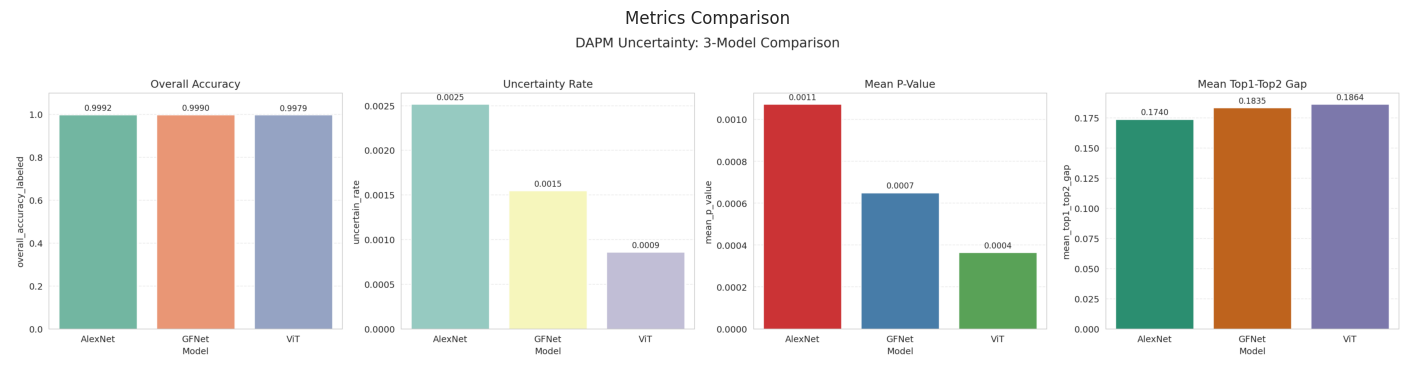

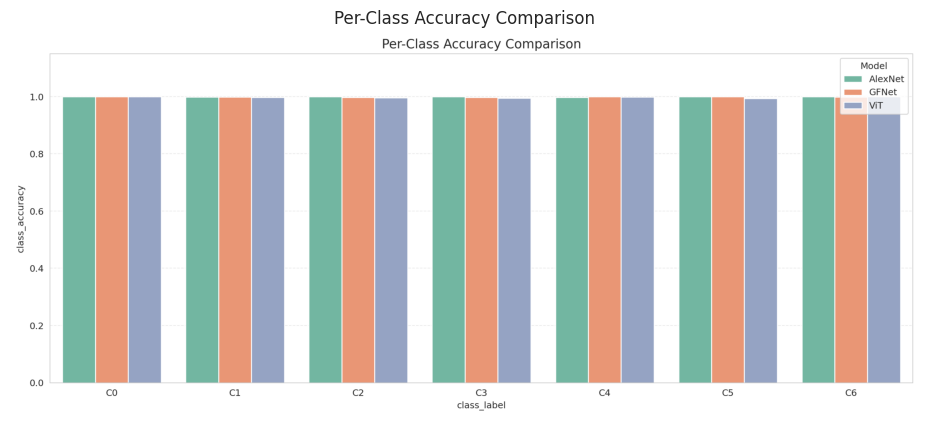

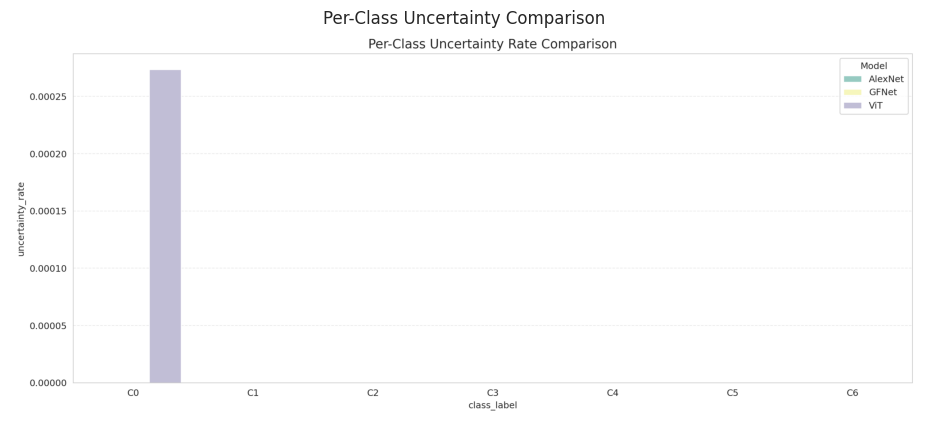

In [17]:
# --- Aggregate DataFrames ---
summary_df = pd.DataFrame(summary_rows)

per_class_all_df = pd.concat(
    [o['per_class_df'].assign(model_name=o['model_name'], model_key=o['model_key'])
     for o in all_outputs],
    ignore_index=True
)


def build_comparison_buffers(sdf, all_out):
    """
    Build cross-model comparison plot buffers.

    Returns a dict of named PNG BytesIO buffers covering summary metrics and
    per-class accuracy / uncertainty rate comparisons across all models.
    """
    bufs    = {}
    metrics = [
        ('overall_accuracy_labeled', 'Overall Accuracy',    'Set2',  (0, 1.1)),
        ('uncertain_rate',           'Uncertainty Rate',    'Set3',  None),
        ('mean_p_value',             'Mean P-Value',        'Set1',  None),
        ('mean_top1_top2_gap',       'Mean Top1-Top2 Gap',  'Dark2', None),
    ]
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    for ax, (col, title, pal, ylim) in zip(axes, metrics):
        sns.barplot(data=sdf, x='model_name', y=col, ax=ax, palette=pal)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Model')
        ax.grid(axis='y', ls='--', alpha=0.4)
        add_bar_labels(ax, fmt='{:.4f}')
        if ylim:
            ax.set_ylim(*ylim)
    fig.suptitle('DAPM Uncertainty: 3-Model Comparison', fontsize=15, y=1.03)
    fig.tight_layout()
    bufs['Metrics Comparison'] = fig_to_buf(fig)

    all_pc = pd.concat(
        [o['per_class_df'].assign(model_name=o['model_name']) for o in all_out],
        ignore_index=True
    )
    all_pc['class_label'] = all_pc['class_id'].apply(lambda c: f'C{c}')

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=all_pc, x='class_label', y='class_accuracy',
                hue='model_name', ax=ax, palette='Set2')
    ax.set_title('Per-Class Accuracy Comparison', fontsize=14)
    ax.set_ylim(0, 1.15)
    ax.legend(title='Model')
    ax.grid(axis='y', ls='--', alpha=0.4)
    fig.tight_layout()
    bufs['Per-Class Accuracy Comparison'] = fig_to_buf(fig)

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=all_pc, x='class_label', y='uncertainty_rate',
                hue='model_name', ax=ax, palette='Set3')
    ax.set_title('Per-Class Uncertainty Rate Comparison', fontsize=14)
    ax.legend(title='Model')
    ax.grid(axis='y', ls='--', alpha=0.4)
    fig.tight_layout()
    bufs['Per-Class Uncertainty Comparison'] = fig_to_buf(fig)

    return bufs


try:
    comparison_bufs = build_comparison_buffers(summary_df, all_outputs)
    print('Comparison plots built successfully')
except Exception as e:
    print(f'Comparison plots failed: {e}')
    comparison_bufs = {}

print(summary_df.to_string(index=False))

# Display comparison plots inline
for name, buf in comparison_bufs.items():
    buf.seek(0)
    img = plt.imread(buf)
    fig, ax = plt.subplots(figsize=(18, 5))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(name)
    plt.show()

In [18]:
# --- Save CSVs and run config JSON ---
summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
per_class_all_df.to_csv(PER_CLASS_CSV_PATH, index=False)

run_config = {
    'seed':             SEED,
    'project_root':     str(PROJECT_ROOT),
    'model_dir':        str(MODEL_DIR),
    'dapm_dir':         str(DAPM_DIR),
    'output_dir':       str(OUTPUT_DIR),
    'data_file':        str(DATA_FILE),
    'label_file':       str(LABEL_FILE),
    'h': H, 'w': W, 'b': B,
    'patch_size':       PATCH_SIZE,
    'n_samples':        N_SAMPLES,
    'p_threshold':      P_THRESH,
    'batch_size':       BATCH_SIZE,
    'scene_chunk_size': SCENE_CHUNK_SIZE,
    'diffusion_steps':  'full_T (per model config)',
    'models':           MODEL_KEYS,
    'timestamp_utc':    pd.Timestamp.utcnow().isoformat(),
}
with open(RUN_CONFIG_JSON_PATH, 'w', encoding='utf-8') as f:
    json.dump(run_config, f, indent=2)

# --- Save rich multi-sheet Excel workbook ---
try:
    used_sheets = set()
    with pd.ExcelWriter(EXCEL_PATH, engine='xlsxwriter') as writer:
        workbook = writer.book

        s = make_sheet_name('Summary_Compact', used_sheets)
        summary_df.to_excel(writer, sheet_name=s, index=False)

        s = make_sheet_name('Run_Config', used_sheets)
        pd.DataFrame(list(run_config.items()),
                     columns=['key', 'value']).to_excel(writer, sheet_name=s, index=False)

        s = make_sheet_name('PerClass_All', used_sheets)
        per_class_all_df.to_excel(writer, sheet_name=s, index=False)

        for output in all_outputs:
            s = make_sheet_name(f'DAPM_{output["model_name"]}', used_sheets)
            write_model_sheet(writer, workbook, output, s)

        if comparison_bufs:
            s = make_sheet_name('Compare_DAPM', used_sheets)
            write_comparison_sheet(writer, workbook, s, summary_df, comparison_bufs)

    print('Saved workbook:', EXCEL_PATH)
except Exception as e:
    print(f'Excel write error: {type(e).__name__}: {e}')
    import traceback
    traceback.print_exc()

print('Saved summary CSV:   ', SUMMARY_CSV_PATH)
print('Saved per-class CSV: ', PER_CLASS_CSV_PATH)
print('Saved run config:    ', RUN_CONFIG_JSON_PATH)

Saved workbook: /content/local_outputs/dapm_full/dapm_full_reports_all_models.xlsx
Saved summary CSV:    /content/local_outputs/dapm_full/dapm_full_summary_metrics.csv
Saved per-class CSV:  /content/local_outputs/dapm_full/dapm_full_per_class_metrics.csv
Saved run config:     /content/local_outputs/dapm_full/dapm_full_run_config.json


# 10.0 — Validation & Copy to Drive

Asserts that all expected output files exist and contain the correct number of rows / sheets,
then copies every local output (workbook, CSVs, JSON, chunk caches, and maps) back to
Google Drive for permanent storage.

In [19]:
from openpyxl import load_workbook as _load_wb

# --- Structural assertions ---
assert EXCEL_PATH.exists(),           f'Workbook missing: {EXCEL_PATH}'
assert SUMMARY_CSV_PATH.exists(),     f'Summary CSV missing'
assert PER_CLASS_CSV_PATH.exists(),   f'Per-class CSV missing'
assert RUN_CONFIG_JSON_PATH.exists(), f'Run config JSON missing'
assert summary_df.shape[0] == 3,      f'Expected 3 summary rows, got {summary_df.shape[0]}'

wb       = _load_wb(EXCEL_PATH, read_only=True)
existing = set(wb.sheetnames)
print(f'Excel sheets: {wb.sheetnames}')
wb.close()

for out in all_outputs:
    pc_total = out['pixel_counts_df']['pixel_count'].sum()
    assert int(pc_total) == H * W, f'Pixel count mismatch for {out["model_key"]}'

print(f'Validation passed. Sheets: {len(existing)}, Summary rows: {len(summary_df)}')

Excel sheets: ['Summary_Compact', 'Run_Config', 'PerClass_All', 'DAPM_AlexNet', 'DAPM_GFNet', 'DAPM_ViT', 'Compare_DAPM']
Validation passed. Sheets: 7, Summary rows: 3


In [20]:
# --- Copy all local outputs back to Drive ---
DRIVE_OUTPUT_DIR = LOCAL_DAPM_DIR_ORIG.parent.parent / 'results' / 'dapm_full'
DRIVE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for f in OUTPUT_DIR.iterdir():
    if f.is_file():
        shutil.copy2(str(f), str(DRIVE_OUTPUT_DIR / f.name))
        print(f'Copied {f.name} → Drive')

DRIVE_CHUNK = DRIVE_OUTPUT_DIR / 'chunk_outputs'
DRIVE_CHUNK.mkdir(parents=True, exist_ok=True)
for f in CHUNK_DIR.iterdir():
    if f.is_file():
        shutil.copy2(str(f), str(DRIVE_CHUNK / f.name))

DRIVE_MAPS = DRIVE_OUTPUT_DIR / 'maps'
DRIVE_MAPS.mkdir(parents=True, exist_ok=True)
for f in MAP_DIR.iterdir():
    if f.is_file():
        shutil.copy2(str(f), str(DRIVE_MAPS / f.name))

print(f'\nAll outputs saved to Drive: {DRIVE_OUTPUT_DIR}')
print(f'  chunks: {sum(1 for _ in DRIVE_CHUNK.iterdir())} files')
print(f'  maps:   {sum(1 for _ in DRIVE_MAPS.iterdir())} files')

Copied dapm_full_run_config.json → Drive
Copied dapm_full_per_class_metrics.csv → Drive
Copied dapm_full_summary_metrics.csv → Drive
Copied dapm_full_reports_all_models.xlsx → Drive

All outputs saved to Drive: /content/drive/My Drive/Classification/dapm/results/dapm_full
  chunks: 306 files
  maps:   39 files
